In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.cluster import KMeans

In [2]:
# Load Image

image = Image.open("pic.jpg")

image_array = np.array(image)

print(image_array.shape)

(6000, 4000, 3)


In [4]:
# Reshape

pixels = image_array.reshape(-1, 3)

print(pixels.shape)

(24000000, 3)


In [15]:
# K-Means

k = 5

kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

kmeans.fit(pixels)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [6]:
# Cluster Labels

labels = kmeans.labels_

centroids = kmeans.cluster_centers_

In [7]:
# Replace Pixels

segmented_pixels = centroids[labels]

In [8]:
# Convert Back 

segmented_image = segmented_pixels.reshape(image_array.shape)

In [9]:
# Convert Type

segmented_image = segmented_image.astype(np.uint8)

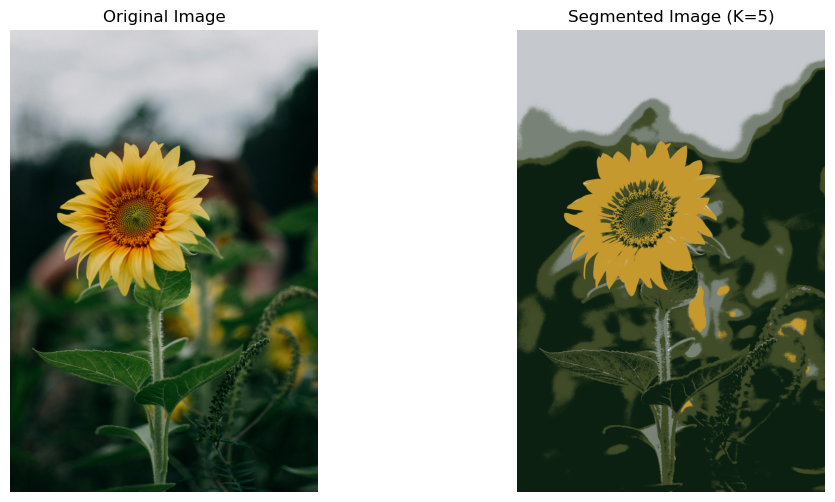

In [10]:
# Display Images

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_array)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented_image)
plt.title("Segmented Image (K=5)")
plt.axis("off")

plt.show()

In [12]:
# Save Result

Image.fromarray(segmented_image).save("segmented_pic.jpg")

#### Running the project for multiple values ​​of K

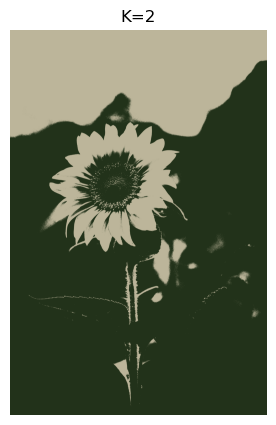

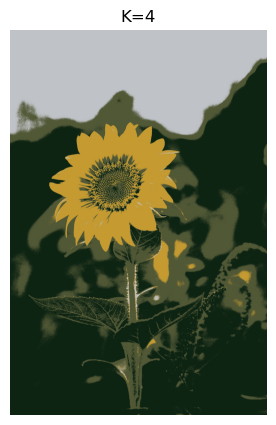

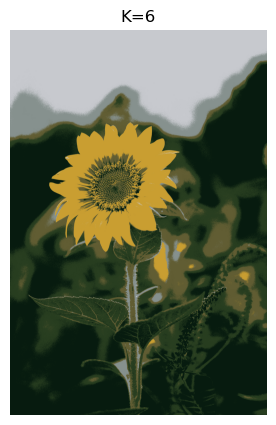

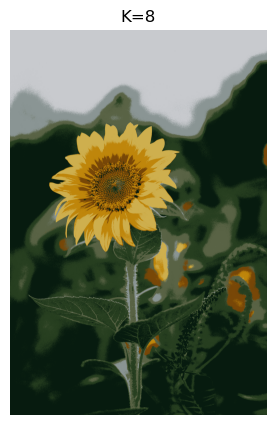

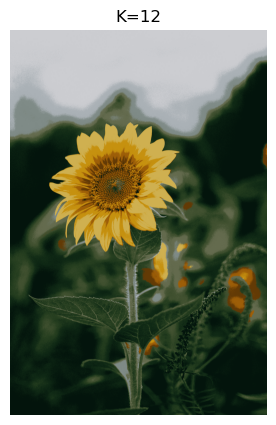

In [16]:
k_values = [2,4,6,8,12]

for k in k_values:

    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

    labels = kmeans.fit_predict(pixels)

    centers = kmeans.cluster_centers_

    segmented = centers[labels]

    segmented = segmented.reshape(image_array.shape)

    segmented = segmented.astype(np.uint8)

    plt.figure(figsize=(5,5))
    plt.imshow(segmented)
    plt.title(f"K={k}")
    plt.axis("off")
    plt.show()

### Report

#### Introduction
The aim of this project was to perform image segmentation using the K-Means clustering algorithm. Image segmentation is the process of partitioning an image into meaningful regions based on pixel similarity.

#### Pre-processing
The image was loaded using the Pillow library and converted into a NumPy array. Each pixel was represented by its RGB values.

The image originally had the shape: Height × Width × 3 and was reshaped into: (Number of Pixels) × 3 ,to make it suitable for K-Means clustering.

#### K-Means Clustering

The K-Means algorithm was applied to the pixel data.

The algorithm iteratively:
1. Initializes cluster centroids.
2. Assigns pixels to the nearest centroid.
3. Updates centroid locations.
4. Repeats until convergence.

The number of clusters was chosen as: K = 5

#### Image Reconstruction

After clustering, each pixel was replaced with the RGB value of its cluster centroid.

The resulting pixel matrix was reshaped back to the original image dimensions to produce the segmented image.

#### Results

The segmented image contained five dominant colour regions. Similar colours were grouped together, reducing image complexity while preserving the overall visual structure.

### Limitations

Several limitations were identified:

- K must be selected manually.
- Sensitive to centroid initialization.
- Spatial information is ignored.
- Complex textures are not handled well.
- Noise can affect clustering quality.

#### Possible Improvements
Potential improvements include:

- K-Means++
- Mini-Batch K-Means
- Gaussian Mixture Models
- Mean Shift
- DBSCAN
- Deep Learning based segmentation
- Using pixel coordinates (x,y) together with RGB values